<a href="https://colab.research.google.com/github/jurados/alercehackton2026/blob/jurados/ZTF_candidates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors

In [ ]:
!pip -q install msal requests


In [ ]:
!pip install astroquery astropy

In [ ]:
!pip install alerce

In [ ]:
!pip -q install alerce astropy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alerce.core import Alerce
from astropy.timeseries import LombScargle
from astropy.coordinates import SkyCoord
import astropy.units as u



In [ ]:
client = Alerce()

cls = client.query_classifiers(format="pandas", survey="ztf")

print(cls.columns)
display(cls.head(20))


In [ ]:
client = Alerce()

#1 Sept 2025
START_MJD = 60918

df = client.query_objects(
    survey="ztf",
    classifier="lc_classifier_BHRF_forced_phot",
    class_name="SNIa",
    probability=0.59,
    order_by="lastmjd",
    order_mode="DESC",
    page_size=2000,
    format="pandas"
)

df["lastmjd"] = pd.to_numeric(df["lastmjd"], errors="coerce")

# filtrar
df_snia = df[df["lastmjd"] >= START_MJD]

print("SNIa encontradas:", len(df_snia))

display(df_snia)

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
tns = pd.read_csv("tns_public_objects.csv", skiprows=1, low_memory=False)

#print("\nColumnas TNS:")
#print(tns.columns.tolist())


tns["ra"] = pd.to_numeric(tns["ra"], errors="coerce")
tns["declination"] = pd.to_numeric(tns["declination"], errors="coerce")
tns["redshift"] = pd.to_numeric(tns["redshift"], errors="coerce")

tns = tns.dropna(subset=["ra", "declination"]).reset_index(drop=True)

#print("Objetos en TNS:", len(tns))
#display(tns.head())

# Cambbio de coordenadas
coords_snia = SkyCoord(
    ra=df_snia["meanra"].values * u.deg,
    dec=df_snia["meandec"].values * u.deg
)

coords_tns = SkyCoord(
    ra=tns["ra"].values * u.deg,
    dec=tns["declination"].values * u.deg
)

#match
idx, sep2d, _ = coords_snia.match_to_catalog_sky(coords_tns)

# umbral de matching
max_sep = 2.0 * u.arcsec
matched = sep2d <= max_sep


df_snia["tns_match"] = matched
df_snia["tns_sep_arcsec"] = sep2d.arcsec

df_snia["tns_name"] = np.where(
    matched,
    tns.iloc[idx]["name"].values,
    None
)

df_snia["tns_name_prefix"] = np.where(
    matched,
    tns.iloc[idx]["name_prefix"].values,
    None
)

df_snia["tns_type"] = np.where(
    matched,
    tns.iloc[idx]["type"].values,
    None
)

df_snia["tns_redshift"] = np.where(
    matched,
    tns.iloc[idx]["redshift"].values,
    np.nan
)

df_snia["tns_full_name"] = np.where(
    matched,
    df_snia["tns_name_prefix"].astype(str) + " " + df_snia["tns_name"].astype(str),
    None
)

print("\nMatches encontrados:", int(df_snia["tns_match"].sum()))
display(df_snia.head())


output_file = "df_snia_with_tns_match.csv"
df_snia.to_csv(output_file, index=False)

print(f"\n Guardado: {output_file}")

In [ ]:
from google.colab import files
files.download("df_snia_with_tns_match.csv")

TABLA COMPLETA

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
display(df_snia)

In [ ]:
output_file = "df_snia_with_tns_match.csv"
df_snia.to_csv(output_file, index=False)

print("Archivo guardado:", output_file)

from google.colab import files
files.download("df_snia_with_tns_match.csv")

LIGHT CURVES

In [ ]:
import os

client = Alerce()

outdir = "lightcurves_snia"
os.makedirs(outdir, exist_ok=True)

all_lcs = []

for oid in df_snia["oid"]:
    try:
        det = client.query_detections(oid, format="pandas")

        forced = client.query_non_detections(oid, format="pandas")

        if det is not None and len(det) > 0:
            det = det.copy()
            det["oid"] = oid

            det.to_csv(f"{outdir}/{oid}_detections.csv", index=False)

            all_lcs.append(det)

        else:
            print(f"Sin detections para {oid}")

    except Exception as e:
        print(f"Error con {oid}: {e}")

if len(all_lcs) > 0:
    df_all_lcs = pd.concat(all_lcs, ignore_index=True)
    output_file = "all_snia_lightcurves.csv"
    df_all_lcs.to_csv(output_file, index=False)

    print(f"Total filas: {len(df_all_lcs)}")
else:
    print("No se pudo descargar ninguna curva de luz")

In [ ]:
from google.colab import files
files.download("all_snia_lightcurves.csv")

In [ ]:
oid_selected = "ZTF25abqamzb"

det = client.query_detections(oid_selected, format="pandas")

if det is not None and len(det) > 0:
    det = det.copy()
    det["oid"] = oid_selected

    output_file = f"{oid_selected}_lightcurve.csv"
    det.to_csv(output_file, index=False)

    print(f"Curva de luz guardada: {output_file}")
    print(f"Total puntos: {len(det)}")
    display(det.head())
else:
    print(f"No se encontraron detections para {oid_selected}")

In [ ]:
# CON ESTO DESCARGAS
from google.colab import files
files.download(output_file)

/tmp/ipykernel_204/1555378965.py:26: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, deg)
/tmp/ipykernel_204/1555378965.py:59: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, deg)


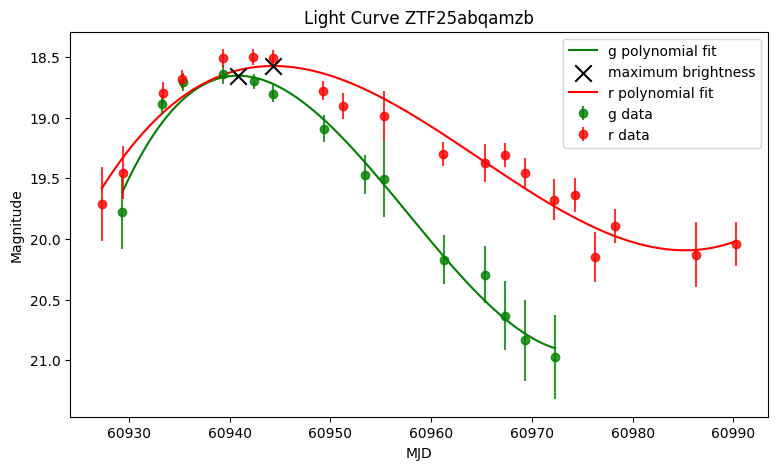

In [59]:
g = det[det["fid"] == 1].copy()
r = det[det["fid"] == 2].copy()

plt.figure(figsize=(9,5))

plt.errorbar(
    g["mjd"], g["magpsf"], yerr=g["sigmapsf"],
    fmt="o", color="green", label="g data",
    alpha=0.8, zorder=2
)

plt.errorbar(
    r["mjd"], r["magpsf"], yerr=r["sigmapsf"],
    fmt="o", color="red", label="r data",
    alpha=0.8, zorder=2
)

deg = 5

# g
if len(g) > deg:

    x = g["mjd"].values
    y = g["magpsf"].values

    p = np.polyfit(x, y, deg)
    poly = np.poly1d(p)

    xfit = np.linspace(x.min(), x.max(), 500)
    yfit = poly(xfit)

    plt.plot(
        xfit, yfit,
        color="green",
        label="g polynomial fit",
        zorder=1
    )

    i = np.argmin(yfit)
    x_max_g = xfit[i]
    y_max_g = yfit[i]

    plt.scatter(
        x_max_g, y_max_g,
        color="black",
        marker="x",
        s=140,
        zorder=5,
        label="maximum brightness"
    )


# r
if len(r) > deg:

    x = r["mjd"].values
    y = r["magpsf"].values

    p = np.polyfit(x, y, deg)
    poly = np.poly1d(p)

    xfit = np.linspace(x.min(), x.max(), 500)
    yfit = poly(xfit)

    plt.plot(
        xfit, yfit,
        color="red",
        label="r polynomial fit",
        zorder=1
    )

    i = np.argmin(yfit)
    x_max_r = xfit[i]
    y_max_r = yfit[i]

    plt.scatter(
        x_max_r, y_max_r,
        color="black",
        marker="x",
        s=140,
        zorder=5
    )


plt.gca().invert_yaxis()
plt.xlabel("MJD")
plt.ylabel("Magnitude")
plt.title(f"Light Curve {oid_selected}")

plt.legend()
plt.show()

# CAMBIO DE MAGNITUDES



In [ ]:
V = r + 0.44 * (g - r) - 0.02
V = B - 1.04*(g-r) - 0.19

r  = B - 1.48*(g-r) - 0.17


http://www.aerith.net/astro/color_conversion.html (NOT SURE)

In [ ]:
df_meta = df_snia[["oid", "tns_redshift", "tns_full_name", "tns_type", "tns_sep_arcsec"]].copy()

df_meta = df_meta.drop_duplicates(subset="oid")
df_meta = df_meta.rename(columns={"tns_redshift": "redshift"})
df_meta = df_meta[df_meta["redshift"].notna()].copy()

print("Objetos con redshift:", len(df_meta))
display(df_meta.head())

df_lc = df_all_lcs.merge(df_meta, on="oid", how="left")

print(df_lc[["oid", "redshift"]].head())